# EDA — Fashion Product Images

Quick look at the dataset before committing to a modeling approach: class balance, how `gender` relates to `masterCategory`, and whether the image size assumption inherited from the original exercise (64x64) actually fits this data.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.data import IMG_SIZE, PROCESSED_DIR, load_label_maps

maps = load_label_maps()
images = np.load(PROCESSED_DIR / f"images_{IMG_SIZE}.npy")
gender_idx = np.load(PROCESSED_DIR / "gender.npy")
label_idx = np.load(PROCESSED_DIR / "labels.npy")

class_names = maps["masterCategory_classes"]
gender_names = maps["gender_classes"]
print(f"{len(images)} images, {len(class_names)} categories, {len(gender_names)} genders")

C:\Users\vitor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.sparse import issparse


44046 images, 5 categories, 5 genders


## Class balance

The raw dataset has 7 `masterCategory` values, but two of them are barely represented at all: **Home** has a single example and **Sporting Goods** has 25, out of 44k+ rows. Neither survives a stratified train/val/test split (you literally can't put 1 example in three splits at once), and training on 25 examples wouldn't produce a meaningful signal either way. `src/data.py` drops any category under `MIN_CLASS_COUNT=100` before building the cache — that's why the chart below shows 5 classes, not 7.

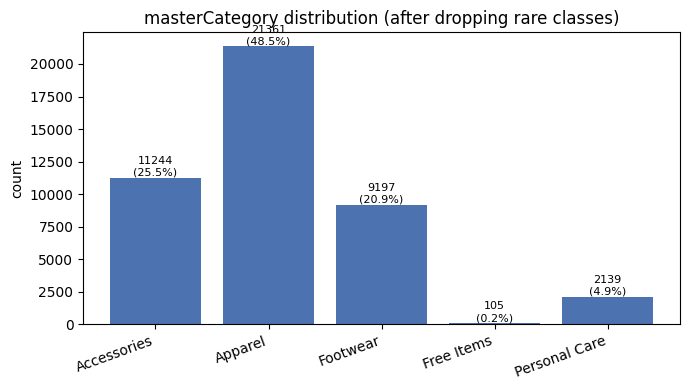

In [2]:
counts = [(label_idx == i).sum() for i in range(len(class_names))]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(class_names, counts, color="#4C72B0")
ax.set_ylabel("count")
ax.set_title("masterCategory distribution (after dropping rare classes)")
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, c, f"{c}\n({c / len(images):.1%})", ha="center", va="bottom", fontsize=8)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Apparel and Accessories dominate, as expected for a fashion catalog. This is exactly why accuracy alone won't tell an honest story later — macro-F1 and per-class F1 are the metrics that actually show whether the model learned the minority classes (Personal Care, Free Items) or just learned to guess Apparel.

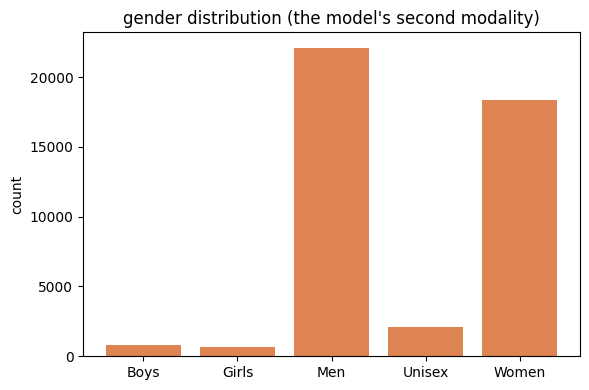

In [3]:
gender_counts = [(gender_idx == i).sum() for i in range(len(gender_names))]
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(gender_names, gender_counts, color="#DD8452")
ax.set_ylabel("count")
ax.set_title("gender distribution (the model's second modality)")
plt.tight_layout()
plt.show()

## Does gender actually carry signal about masterCategory?

This is the question the whole baseline-vs-proposed comparison hinges on. If gender and masterCategory are independent, adding the `gender_layer` branch shouldn't help — and the case study should say so honestly rather than manufacture a lift.

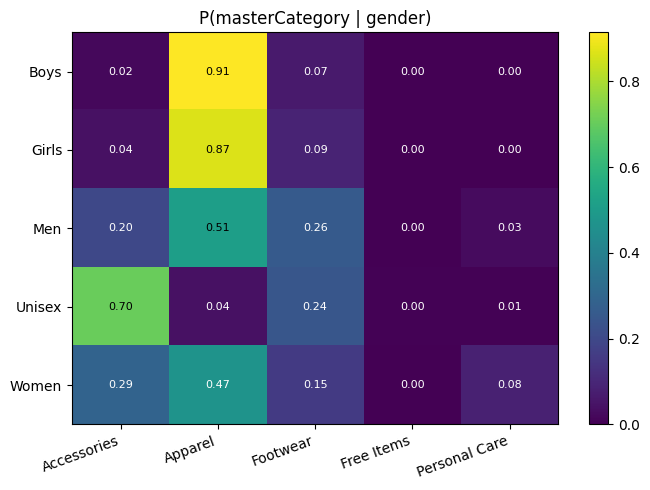

In [4]:
crosstab = np.zeros((len(gender_names), len(class_names)))
for g in range(len(gender_names)):
    mask = gender_idx == g
    total = mask.sum()
    for c in range(len(class_names)):
        crosstab[g, c] = (label_idx[mask] == c).sum() / total if total else 0

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(crosstab, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=20, ha="right")
ax.set_yticks(range(len(gender_names)))
ax.set_yticklabels(gender_names)
ax.set_title("P(masterCategory | gender)")
for g in range(len(gender_names)):
    for c in range(len(class_names)):
        ax.text(c, g, f"{crosstab[g, c]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if crosstab[g, c] < 0.5 else "black")
fig.colorbar(im)
plt.tight_layout()
plt.show()

Rows differ visibly (e.g. Personal Care's share shifts by gender, and the category mix for Boys/Girls looks different from Men/Women/Unisex) — so there's real, explainable signal here, not just noise. That's a reasonable basis to expect the multi-modal model to beat the image-only baseline. The actual lift gets measured properly in `02_case_study.ipynb`, after both models are trained.

## Image size sanity check

The original cert exercise used 64x64 grayscale, inherited from a synthetic dataset. These are real RGB product photos at roughly 60x80 — closer to a 3:4 portrait crop than a square. Resizing down to 64x64 would distort the aspect ratio more than necessary; 80x80 (still square, still cheap to train) keeps more of the original detail. Decision: **80x80, RGB** (see `src/data.py:IMG_SIZE`).

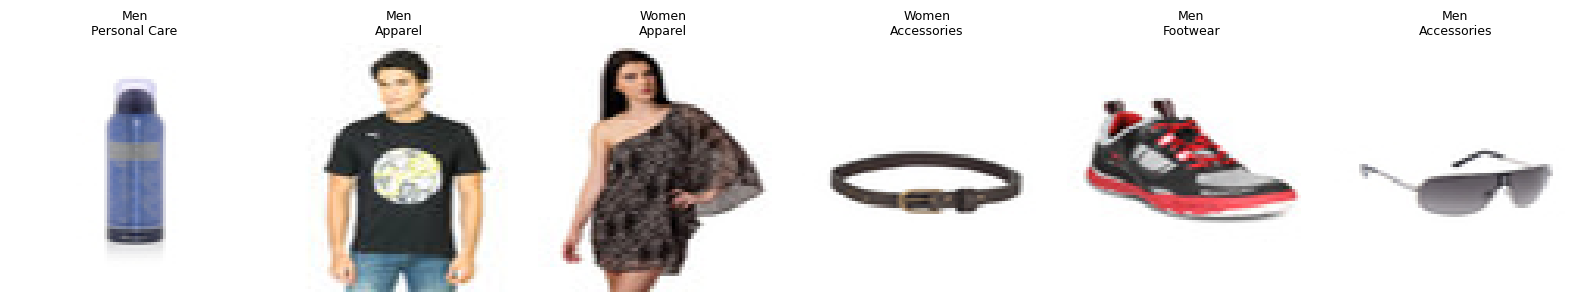

In [5]:
rng = np.random.default_rng(7)
sample_idx = rng.choice(len(images), size=6, replace=False)
fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for ax, idx in zip(axes, sample_idx):
    ax.imshow(images[idx])
    ax.set_title(f"{gender_names[gender_idx[idx]]}\n{class_names[label_idx[idx]]}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()